<a href="https://colab.research.google.com/github/marina-popova11/MambaModelPrediction/blob/train/mamba_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers torch
!pip install pandas numpy scikit-learn tqdm torch matplotlib
!pip install mamba-ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.8/260.8 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 61.9 MB/s eta 0:00:00
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl size=322288410 sha256=7a67070c1e7e99c95abd1319623f044e8a1b3fb46f774bfdea949f0a4fc79638
  Stored in directory: /root/.cache/pip/wheels/da/67/03/99148d6eeaa4ec2855d71295ac83bcbc8ba7b41a2982992c63
Successfully built mamba-ssm


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import pickle
import os

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def prepare_data_internal(df, lookback=60, n_bins=5, classification_mode=True):
    df = df.sort_values('Open time').reset_index(drop=True)
    df['Open time'] = pd.to_datetime(df['Open time'])
    if classification_mode:
        if 'target_class' not in df.columns:
            raise ValueError("Колонка 'target_class' не найдена. Запустите сначала create_discrete_targets_quantile.")

        target_col_raw = 'target_class'

        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        df['target_encoded'] = le.fit_transform(df[target_col_raw])

        target_col = 'target_encoded'
        class_labels = list(le.classes_) # Сохраняем порядок классов: ['neutral', 'strong_down'...]

        class_medians = df.groupby(target_col)['target_return'].median().to_dict()

    else:
        target_col = 'target_return'
        class_labels = None
        class_medians = None

    feature_cols = [
        'Open', 'High', 'Low', 'Close', 'Volume',
        'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
        'Taker buy quote asset volume', 'returns', 'log_return',
        'norm_return', 'norm_return_lag_1', 'norm_return_lag_2',
        'norm_return_lag_3', 'norm_return_lag_6', 'norm_return_lag_12',
        'norm_return_lag_24', 'norm_return_sma_12', 'norm_return_sma_24',
        'norm_return_ema_12', 'volatility_returns', 'volatility_log', 'rsi',
        'vol_ratio', 'log_return_lag_1', 'log_return_lag_2', 'log_return_lag_3',
        'volume_ma', 'volume_ratio', 'volume_norm'
    ]

    feature_cols = [col for col in feature_cols if col in df.columns]

    df = df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)

    total_len = len(df)
    train_end = int(total_len * 0.70)
    val_end = int(total_len * 0.85)

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    from sklearn.preprocessing import RobustScaler
    scaler_features = RobustScaler(quantile_range=(10.0, 90.0))

    scaler_features.fit(train_df[feature_cols])
    train_scaled = scaler_features.transform(train_df[feature_cols])
    val_scaled = scaler_features.transform(val_df[feature_cols])
    test_scaled = scaler_features.transform(test_df[feature_cols])

    if classification_mode:
        y_train = train_df[target_col].values.astype(np.int64)
        y_val = val_df[target_col].values.astype(np.int64)
        y_test = test_df[target_col].values.astype(np.int64)
    else:
        from sklearn.preprocessing import StandardScaler
        scaler_target = StandardScaler()
        scaler_target.fit(train_df[[target_col]])
        y_train = scaler_target.transform(train_df[[target_col]]).flatten()
        y_val = scaler_target.transform(val_df[[target_col]]).flatten()
        y_test = scaler_target.transform(test_df[[target_col]]).flatten()

    def create_windows(features, targets):
        X, y = [], []
        for i in range(lookback, len(features)):
            X.append(features[i-lookback:i])
            y.append(targets[i])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64 if classification_mode else np.float32)

    X_train, y_train = create_windows(train_scaled, y_train)
    X_val, y_val = create_windows(val_scaled, y_val)
    X_test, y_test = create_windows(test_scaled, y_test)

    time_train = df['Open time'].iloc[lookback:train_end].values
    time_val = df['Open time'].iloc[train_end+lookback:val_end].values
    time_test = df['Open time'].iloc[val_end+lookback:].values

    print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")
    if classification_mode:
        unique, counts = np.unique(y_train, return_counts=True)
        print(f"Class distribution in Train: {dict(zip(unique, counts))}")

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'scaler_features': scaler_features,
        'feat_cols': feature_cols,
        'time_index': {'train': time_train, 'val': time_val, 'test': time_test},
        'classification_mode': classification_mode,
        'class_labels': class_labels,      # Чтобы знать, что класс 0 - это 'neutral' и т.д.
        'class_medians': class_medians,    # Чтобы понимать среднюю доходность класса
        'n_classes': n_bins if classification_mode else None,
        'target_col': target_col
    }

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def prepare_data_internal(df, lookback=60, n_bins=5, classification_mode=True, metadata_path='bin_metadata.pkl'):
    df = df.sort_values('Open time').reset_index(drop=True)
    df['Open time'] = pd.to_datetime(df['Open time'])

    class_labels = None
    bin_edges = None
    class_medians = {}
    if classification_mode:
        target_col = None
        if 'target_class' in df.columns:
            from sklearn.preprocessing import LabelEncoder
            target_col = 'target_class'
            le = LabelEncoder()
            df['target_class'] = le.fit_transform(df[target_col])
            target_col = 'target_class'
            class_labels = [str(c) for c in le.classes_]
            if os.path.exists(metadata_path):
                with open(metadata_path, 'rb') as f:
                    metadata = pickle.load(f)
                    bin_edges = metadata.get('bin_edges')
                    raw_medians = metadata.get('class_medians', {})
                    label_to_idx = {label: idx for idx, label in enumerate(le.classes_)}
                    for orig_label, median_val in raw_medians.items():
                        if orig_label in label_to_idx:
                            class_medians[label_to_idx[orig_label]] = median_val
            else:
                print("ВНИМАНИЕ: bin_metadata.pkl не найден!")
                print("Вычисление метаданных из данных...")
                bin_edges = None
                class_medians = df.groupby(target_col)['target_return'].median().to_dict()
                class_labels = [f'class_{i}' for i in range(n_bins)]
        elif 'target_label' in df.columns:
            target_col = 'target_label'
            le = LabelEncoder()
            df['target_class_encoded'] = le.fit_transform(df[target_col])
            target_col = 'target_class_encoded'
            class_labels = list(le.classes_)
            class_medians = df.groupby(target_col)['target_return'].median().to_dict()
        else:
            raise ValueError("No target_class or target_label column found in data!")
    else:
        target_col = 'target_return'

    feature_cols = [
        'Open', 'High', 'Low', 'Close', 'Volume',
        'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
        'Taker buy quote asset volume', 'returns', 'log_return',
        'norm_return', 'norm_return_lag_1', 'norm_return_lag_2',
        'norm_return_lag_3', 'norm_return_lag_6', 'norm_return_lag_12',
        'norm_return_lag_24', 'norm_return_sma_12', 'norm_return_sma_24',
        'norm_return_ema_12', 'volatility_returns', 'volatility_log', 'rsi',
        'vol_ratio', 'log_return_lag_1', 'log_return_lag_2', 'log_return_lag_3',
        'volume_ma', 'volume_ratio', 'volume_norm'
    ]

    feature_cols = [col for col in feature_cols if col in df.columns]

    df = df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)

    total_len = len(df)
    train_end = int(total_len * 0.70)
    val_end = int(total_len * 0.85)

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    scaler_features = RobustScaler(quantile_range=(10.0, 90.0))
    scaler_features.fit(train_df[feature_cols])

    train_scaled_features = scaler_features.transform(train_df[feature_cols])
    val_scaled_features = scaler_features.transform(val_df[feature_cols])
    test_scaled_features = scaler_features.transform(test_df[feature_cols])

    if classification_mode:
        train_target = train_df[target_col].values.astype(np.int64)
        val_target = val_df[target_col].values.astype(np.int64)
        test_target = test_df[target_col].values.astype(np.int64)
        scaler_target = None
    else:
        scaler_target = StandardScaler()
        scaler_target.fit(train_df[[target_col]])
        train_target = scaler_target.transform(train_df[[target_col]]).flatten()
        val_target = scaler_target.transform(val_df[[target_col]]).flatten()
        test_target = scaler_target.transform(test_df[[target_col]]).flatten()

    def create_windows(features, targets):
        X, y = [], []
        for i in range(lookback, len(features)):
            X.append(features[i-lookback:i])
            y.append(targets[i])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64 if classification_mode else np.float32)

    X_train, y_train = create_windows(train_scaled_features, train_target)
    X_val, y_val = create_windows(val_scaled_features, val_target)
    X_test, y_test = create_windows(test_scaled_features, test_target)

    time_train = df['Open time'].iloc[lookback:train_end].values
    time_val = df['Open time'].iloc[train_end+lookback:val_end].values
    time_test = df['Open time'].iloc[val_end+lookback:].values

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'scaler_features': scaler_features,
        'scaler_target': scaler_target,
        'feat_cols': feature_cols,
        'time_index': {'train': time_train, 'val': time_val, 'test': time_test},
        'classification_mode': classification_mode,
        'n_classes': n_bins if classification_mode else None,
        'bin_edges': bin_edges,
        'class_medians': class_medians,
        'class_labels': class_labels,
        'target_col': target_col
    }

In [ ]:
def get_data_loaders(filename, lookback=60, batch_size=128, cache_file='data_cache.pkl',
                     n_bins=5, classification_mode=True, force_reprocess=False):
    cache_key = f"{cache_file}_{lookback}_{n_bins}_{classification_mode}"

    if os.path.exists(cache_key) and not force_reprocess:
        print(f"Загрузка кэшированных данных из {cache_key}...")
        with open(cache_key, 'rb') as f:
            data_dict = pickle.load(f)
    else:
        print(f"Обработка данных из {filename} (это займет время)...")
        df = pd.read_csv(filename)
        data_dict = prepare_data_internal(df, lookback, n_bins, classification_mode)

        with open(cache_key, 'wb') as f:
            pickle.dump(data_dict, f)
        print(f"Кэш сохранен в {cache_key}")

    def make_loader(X, y, shuffle=False):
        if classification_mode:
            dataset = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
        else:
            dataset = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

    train_loader = make_loader(data_dict['X_train'], data_dict['y_train'], shuffle=True)
    val_loader = make_loader(data_dict['X_val'], data_dict['y_val'], shuffle=False)
    test_loader = make_loader(data_dict['X_test'], data_dict['y_test'], shuffle=False)

    print(f"Данные готовы: Train={len(data_dict['X_train'])}, Val={len(data_dict['X_val'])}, Test={len(data_dict['X_test'])}")
    print(f"Режим: {'Классификация' if classification_mode else 'Регрессия'}")
    if classification_mode:
        print(f"Количество классов: {data_dict['n_classes']}")
        unique, counts = np.unique(data_dict['y_train'], return_counts=True)
        print(f"Распределение классов в train: {dict(zip(unique, counts))}")

    return data_dict, train_loader, val_loader, test_loader

In [ ]:
import torch.nn as nn
import torch.optim as optim

class MambaModel(nn.Module):
    def __init__(self, input_dim, n_classes=5,  d_model=128, n_layers=3, use_mamba=True):
        super().__init__()
        self.use_mamba = use_mamba
        self.n_classes = n_classes
        self.drop1 = nn.Dropout(0.1)
        self.drop2 = nn.Dropout(0.1)
        self.input_proj = nn.Linear(input_dim, d_model)

        if use_mamba:
            try:
                from mamba_ssm import Mamba
                print("Using Mamba Architecture")
                self.blocks = nn.ModuleList([
                    Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2)
                    for _ in range(n_layers)
                ])
            except ImportError:
                print("Mamba not installed. Falling back to LSTM.")
                self.use_mamba = False

        if not self.use_mamba:
            print("Using LSTM Architecture (Fallback)")
            self.lstm = nn.LSTM(input_size=d_model, hidden_size=d_model, num_layers=n_layers, batch_first=True, dropout=0.0)

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.drop1(x)
        if self.use_mamba:
            for block in self.blocks:
                x = block(x)
        else:
            x, _ = self.lstm(x)
        x = self.drop2(x)
        x = self.norm(x)
        last_hidden = x[:, -1, :]
        logits = self.head(last_hidden)
        return logits

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

def run_training_classification(model, train_loader, val_loader, epochs=20,
                                learning_rate=3e-4, early_stop_patience=10,
                                model_path="best_mamba_classifier.pth",
                                class_weights=None):
    device = next(model.parameters()).device
    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
        print("Using weighted CrossEntropyLoss")
    else:
        criterion = nn.CrossEntropyLoss()
        print("Using standard CrossEntropyLoss")

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_val_loss = float('inf')
    best_val_acc = 0.0
    patience_counter = 0
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    print("\nStarting Training(Classification)...")
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} [Train]"):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)  # [batch, n_classes]
            loss = criterion(logits, yb)

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"DETECTED NaN/Inf Loss! Stopping.")
                return None

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

            _, predicted = torch.max(logits, 1)
            train_total += yb.size(0)
            train_correct += (predicted == yb).sum().item()

        train_loss /= len(train_loader)
        train_acc = train_correct / train_total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for xb, yb in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} [Val]"):
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item()

                _, predicted = torch.max(logits, 1)
                val_total += yb.size(0)
                val_correct += (predicted == yb).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch + 1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            torch.save({
                'model_state_dict': model.state_dict(),
                'best_val_acc': best_val_acc,
                'epoch': epoch
            }, model_path)
            print(f"-> Saved new best model! (Val Acc: {val_acc:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    print(f"\nTraining finished. Best Val Acc: {best_val_acc:.4f}, Best Val Loss: {best_val_loss:.4f}")
    return history

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

def evaluate_classification(model, test_loader, class_medians, class_labels,
                            time_index=None, model_path="best_mamba_classifier.pth"):
    print("Keys in class_medians:", list(class_medians.keys()))
    print("Expected class indices:", list(range(len(class_labels))))
    assert set(class_medians.keys()) == set(range(len(class_labels))), "Mismatch!"
    device = next(model.parameters()).device

    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"\nEvaluating on Test Set... (Best Val Acc: {checkpoint['best_val_acc']:.4f})")

    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)  # [batch, n_classes]
            preds = torch.argmax(logits, dim=1)  # [batch]

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)

    accuracy = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='weighted')
    conf_matrix = confusion_matrix(all_targets, all_preds)

    print(f"\n=== CLASSIFICATION RESULTS ===")
    print(f"Accuracy: {accuracy:.4f} ({accuracy:.2%})")
    print(f"Weighted F1-Score: {f1:.4f}")
    print(f"\nClassification Report:")
    report = classification_report(all_targets, all_preds,
                                   target_names=class_labels,
                                   zero_division=0)
    print(report)

    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix (Accuracy: {accuracy:.2%})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()

    if class_medians:
        pred_log_returns = np.array([class_medians[p] for p in all_preds])
        true_log_returns = np.array([class_medians[t] for t in all_targets])
        rmse_log = np.sqrt(np.mean((pred_log_returns - true_log_returns) ** 2))
        mae_log = np.mean(np.abs(pred_log_returns - true_log_returns))

        print(f"\n=== PRICE SPACE METRICS (using class medians) ===")
        print(f"RMSE (log-return): {rmse_log:.6f}")
        print(f"MAE (log-return): {mae_log:.6f}")
        print(f"Это соответствует ошибке в цене ~ {mae_log * 100:.2f}%")

        pred_direction = np.sign(pred_log_returns)
        true_direction = np.sign(true_log_returns)
        dir_accuracy = np.mean(pred_direction == true_direction)
        print(f"Direction Accuracy: {dir_accuracy:.4f} ({dir_accuracy:.2%})")

        if time_index is not None and len(time_index) == len(all_targets):
            fig, axes = plt.subplots(2, 1, figsize=(14, 10))

            #Сравнение классов
            axes[0].plot(time_index, all_targets, label='Actual Class', color='blue', alpha=0.6)
            axes[0].plot(time_index, all_preds, label='Predicted Class', color='red', alpha=0.6, linestyle='--')
            axes[0].set_ylabel('Class Index')
            axes[0].set_title(f'Class Predictions (Accuracy: {accuracy:.2%})')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            # Log-returns (через медианы)
            axes[1].plot(time_index, true_log_returns, label='Actual Log-Return', color='blue', alpha=0.7)
            axes[1].plot(time_index, pred_log_returns, label='Predicted Log-Return', color='red', alpha=0.7, linestyle='--')
            axes[1].set_ylabel('Log-Return')
            axes[1].set_title(f'Log-Returns from Class Medians (Dir Acc: {dir_accuracy:.2%})')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig('classification_results.png', dpi=150)
            plt.show()

    return accuracy, f1

Обработка данных из btc_1h_2020-2025_training_sample_with_bins_second.csv (это займет время)...
Train shape: (36161, 120, 31), Val shape: (7654, 120, 31), Test shape: (7655, 120, 31)
Class distribution in Train: {np.int64(0): np.int64(7132), np.int64(1): np.int64(7463), np.int64(2): np.int64(7651), np.int64(3): np.int64(7062), np.int64(4): np.int64(6853)}
Кэш сохранен в processed_data_cache.pkl_120_5_True
Данные готовы: Train=36161, Val=7654, Test=7655
Режим: Классификация
Количество классов: 5
Распределение классов в train: {np.int64(0): np.int64(7132), np.int64(1): np.int64(7463), np.int64(2): np.int64(7651), np.int64(3): np.int64(7062), np.int64(4): np.int64(6853)}
Class weights: tensor([1.0140, 0.9691, 0.9453, 1.0241, 1.0553])
Using Mamba Architecture
Using weighted CrossEntropyLoss

Starting Training(Classification)...


Epoch 1/20 [Val]: 100%|██████████| 60/60 [00:00<00:00, 105.98it/s]


Epoch 1: Train Loss=1.5822, Train Acc=0.2611 | Val Loss=1.6436, Val Acc=0.1969
-> Saved new best model! (Val Acc: 0.1969)


Epoch 2/20 [Val]: 100%|██████████| 60/60 [00:00<00:00, 103.62it/s]


Epoch 2: Train Loss=1.5687, Train Acc=0.2753 | Val Loss=1.6242, Val Acc=0.2007
-> Saved new best model! (Val Acc: 0.2007)


...

Epoch 12: Train Loss=1.4557, Train Acc=0.3613 | Val Loss=1.8146, Val Acc=0.1991


Epoch 13/20 [Val]: 100%|██████████| 60/60 [00:00<00:00, 105.87it/s]


Epoch 13: Train Loss=1.4413, Train Acc=0.3726 | Val Loss=1.8502, Val Acc=0.1928


Epoch 14/20 [Val]: 100%|██████████| 60/60 [00:00<00:00, 106.57it/s]


Epoch 14: Train Loss=1.4287, Train Acc=0.3816 | Val Loss=1.8468, Val Acc=0.1883
Early stopping at epoch 14

Training finished. Best Val Acc: 0.2174, Best Val Loss: 1.6161
Keys in class_medians: [0, 1, 2, 3, 4]
Expected class indices: [0, 1, 2, 3, 4]

Evaluating on Test Set... (Best Val Acc: 0.2174)

=== CLASSIFICATION RESULTS ===
Accuracy: 0.2206 (22.06%)
Weighted F1-Score: 0.1125

Classification Report:
              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00      1749
 strong_down       0.17      0.13      0.15      1331
   strong_up       0.00      0.00      0.00      1026
   weak_down       0.13      0.01      0.01      1756
     weak_up       0.23      0.84      0.36      1793

    accuracy                           0.22      7655
   macro avg       0.11      0.19      0.10      7655
weighted avg       0.11      0.22      0.11      7655



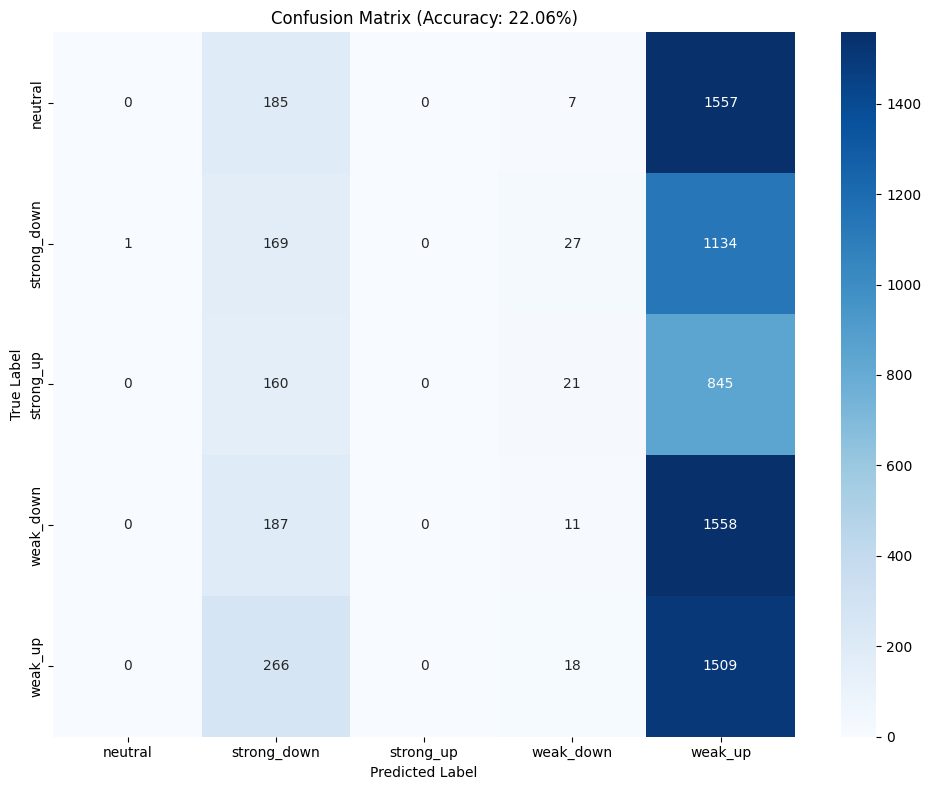


=== PRICE SPACE METRICS (using class medians) ===
RMSE (log-return): 0.025366
MAE (log-return): 0.019677
Это соответствует ошибке в цене ~ 1.97%
Direction Accuracy: 0.5624 (56.24%)


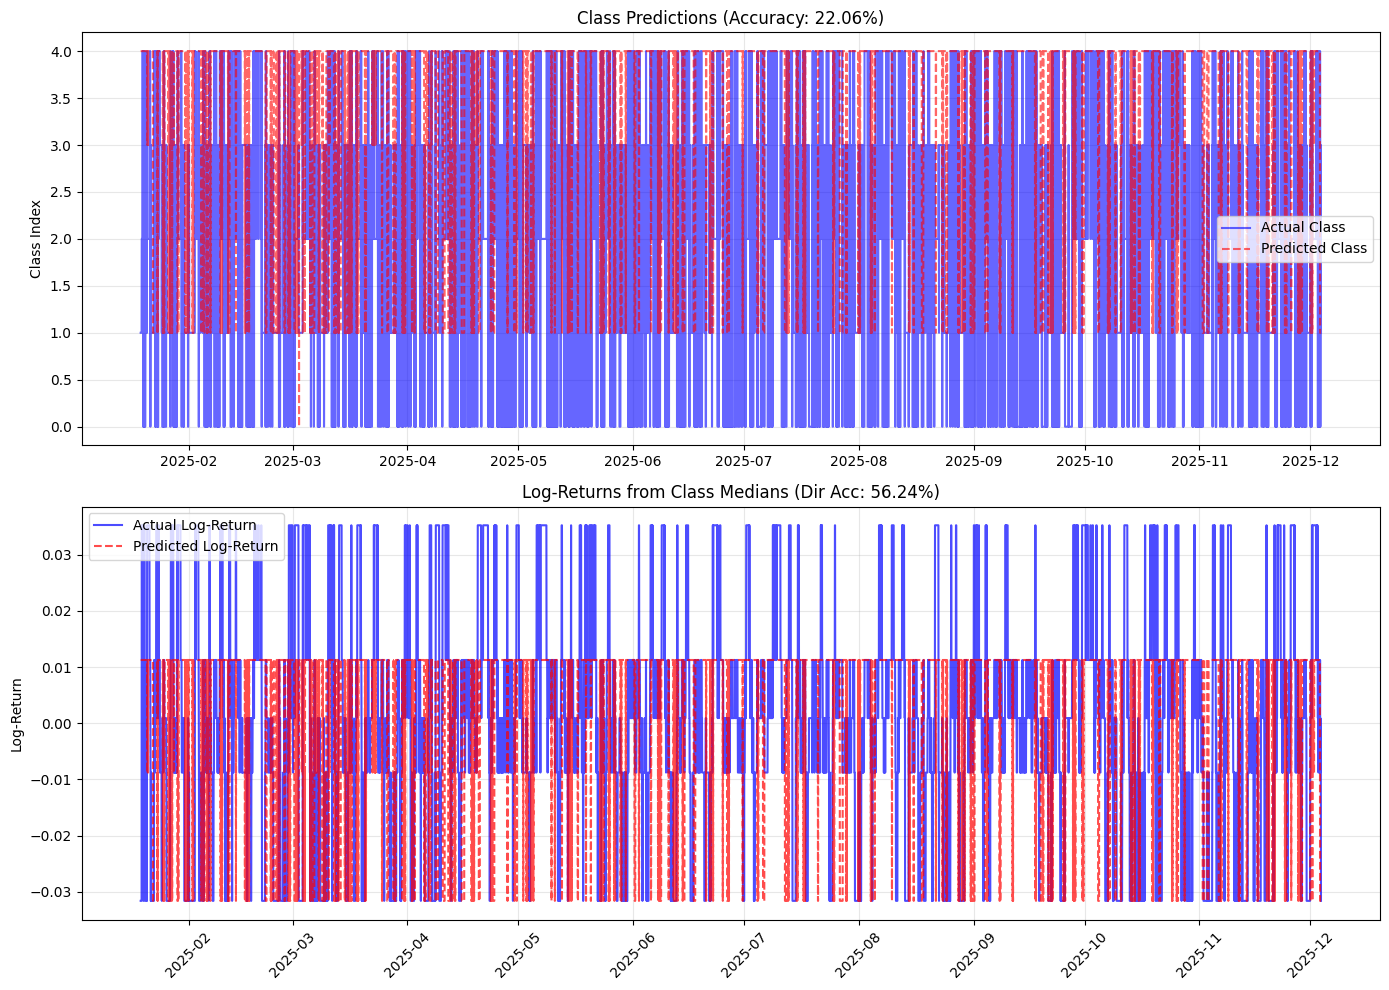

In [ ]:
# acc 22, dir acc 56

if __name__ == "__main__":
    LOOKBACK = 120
    BATCH_SIZE = 128
    EPOCHS = 20
    D_MODEL = 128
    N_LAYERS = 2
    N_BINS = 5
    CSV_FILE = 'btc_1h_2020-2025_training_sample_with_bins_second.csv'
    CACHE_FILE = 'processed_data_cache.pkl'
    MODEL_PATH = 'best_mamba_classifier.pth'

    data_dict, train_loader, val_loader, test_loader = get_data_loaders(
        filename=CSV_FILE,
        lookback=LOOKBACK,
        batch_size=BATCH_SIZE,
        cache_file=CACHE_FILE,
        n_bins=N_BINS,
        classification_mode=True,
        force_reprocess=True
    )

    input_dim = data_dict['X_train'].shape[2]
    n_classes = data_dict['n_classes']
    class_labels = data_dict['class_labels']
    class_medians = data_dict['class_medians']

    from sklearn.utils.class_weight import compute_class_weight
    class_weights_np = compute_class_weight('balanced', classes=np.unique(data_dict['y_train']), y=data_dict['y_train'])
    class_weights_tensor = torch.FloatTensor(class_weights_np)
    print(f"Class weights: {class_weights_tensor}")

    model = MambaModel(
        input_dim=input_dim,
        n_classes=n_classes,
        d_model=D_MODEL,
        n_layers=N_LAYERS,
        use_mamba=True
    ).to(device)

    history = run_training_classification(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS,
        learning_rate=3e-4,
        early_stop_patience=10,
        model_path=MODEL_PATH,
        class_weights=class_weights_tensor
    )

    if history is not None:
        evaluate_classification(
            model=model,
            test_loader=test_loader,
            class_medians=class_medians,
            class_labels=class_labels,
            time_index=data_dict['time_index']['test'],
            model_path=MODEL_PATH
        )

Keys in class_medians: [0, 1, 2, 3, 4]
Expected class indices: [0, 1, 2, 3, 4]

Evaluating on Test Set... (Best Val Acc: 0.2228)

=== CLASSIFICATION RESULTS ===
Accuracy: 0.1762 (17.62%)
Weighted F1-Score: 0.1693

Classification Report:
              precision    recall  f1-score   support

     neutral       0.24      0.11      0.15      1749
 strong_down       0.17      0.29      0.21      1331
   strong_up       0.12      0.26      0.16      1026
   weak_down       0.22      0.07      0.11      1756
     weak_up       0.23      0.20      0.21      1793

    accuracy                           0.18      7655
   macro avg       0.19      0.19      0.17      7655
weighted avg       0.20      0.18      0.17      7655



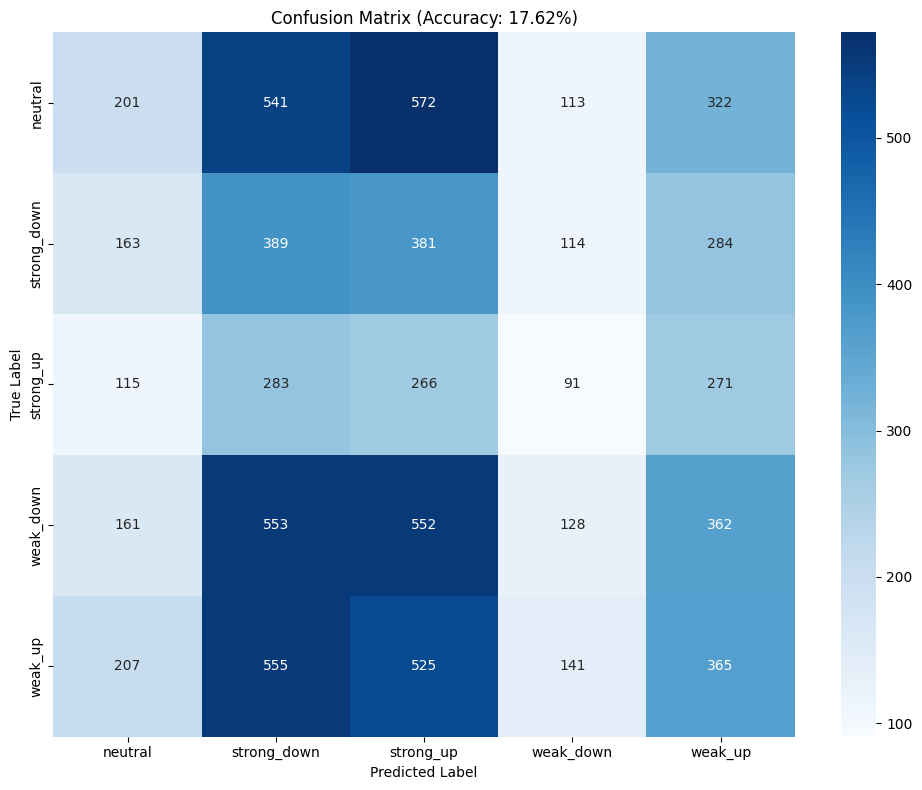


=== PRICE SPACE METRICS (using class medians) ===
RMSE (log-return): 0.033131
MAE (log-return): 0.027134
Это соответствует ошибке в цене ~ 2.71%
Direction Accuracy: 0.5262 (52.62%)


In [ ]:
if history is not None:
    evaluate_classification(
        model=model,
        test_loader=test_loader,
        class_medians=class_medians,
        class_labels=class_labels,
        time_index=None,
        model_path=MODEL_PATH
    )

Загрузка кэшированных данных из processed_data_cache.pkl_60_5_True...
Данные готовы: Train=36221, Val=7714, Test=7715
Режим: Классификация
Количество классов: 5
Распределение классов в train: {np.int64(0): np.int64(7496), np.int64(1): np.int64(7058), np.int64(2): np.int64(7106), np.int64(3): np.int64(6882), np.int64(4): np.int64(7679)}
Class weights: tensor([0.9664, 1.0264, 1.0194, 1.0526, 0.9434])
Using Mamba Architecture
Using weighted CrossEntropyLoss

Starting Training(Classification)...


Epoch 1/20 [Val]: 100%|██████████| 61/61 [00:00<00:00, 158.51it/s]


Epoch 1: Train Loss=1.5797, Train Acc=0.2627 | Val Loss=1.6145, Val Acc=0.2254
-> Saved new best model! (Val Acc: 0.2254)


Epoch 2/20 [Val]: 100%|██████████| 61/61 [00:00<00:00, 156.73it/s]


Epoch 2: Train Loss=1.5656, Train Acc=0.2768 | Val Loss=1.6314, Val Acc=0.2192


...

Epoch 9: Train Loss=1.5039, Train Acc=0.3329 | Val Loss=1.6305, Val Acc=0.2042


Epoch 10/20 [Val]: 100%|██████████| 61/61 [00:00<00:00, 151.69it/s]


Epoch 10: Train Loss=1.4861, Train Acc=0.3455 | Val Loss=1.6705, Val Acc=0.2059


Epoch 11/20 [Val]: 100%|██████████| 61/61 [00:00<00:00, 154.03it/s]


Epoch 11: Train Loss=1.4573, Train Acc=0.3657 | Val Loss=1.6820, Val Acc=0.1951
Early stopping at epoch 11

Training finished. Best Val Acc: 0.2254, Best Val Loss: inf

Evaluating on Test Set... (Best Val Acc: 0.2254)

=== CLASSIFICATION RESULTS ===
Accuracy: 0.2340 (23.40%)
Weighted F1-Score: 0.1494

Classification Report:
              precision    recall  f1-score   support

     class_0       0.19      0.40      0.26      1325
     class_1       0.25      0.66      0.37      1774
     class_2       0.00      0.00      0.00      1776
     class_3       0.14      0.00      0.00      1800
     class_4       0.35      0.10      0.15      1040

    accuracy                           0.23      7715
   macro avg       0.19      0.23      0.16      7715
weighted avg       0.17      0.23      0.15      7715



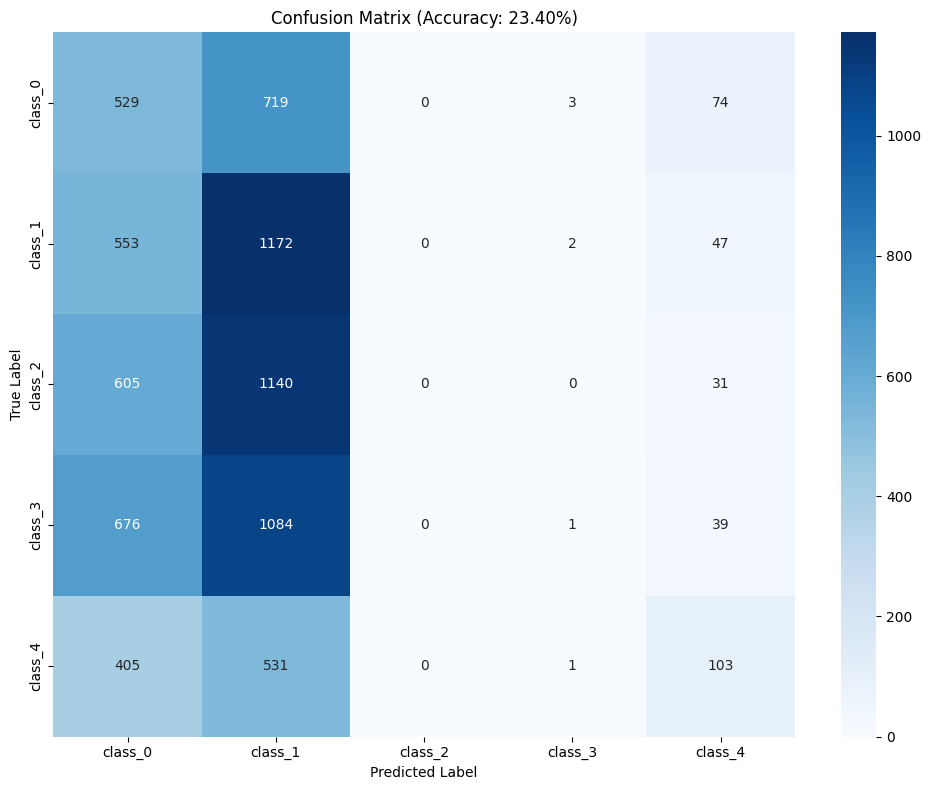


=== PRICE SPACE METRICS (using class medians) ===
RMSE (log-return): 0.029538
MAE (log-return): 0.022614
Это соответствует ошибке в цене ~ 2.26%
Direction Accuracy: 0.4080 (40.80%)


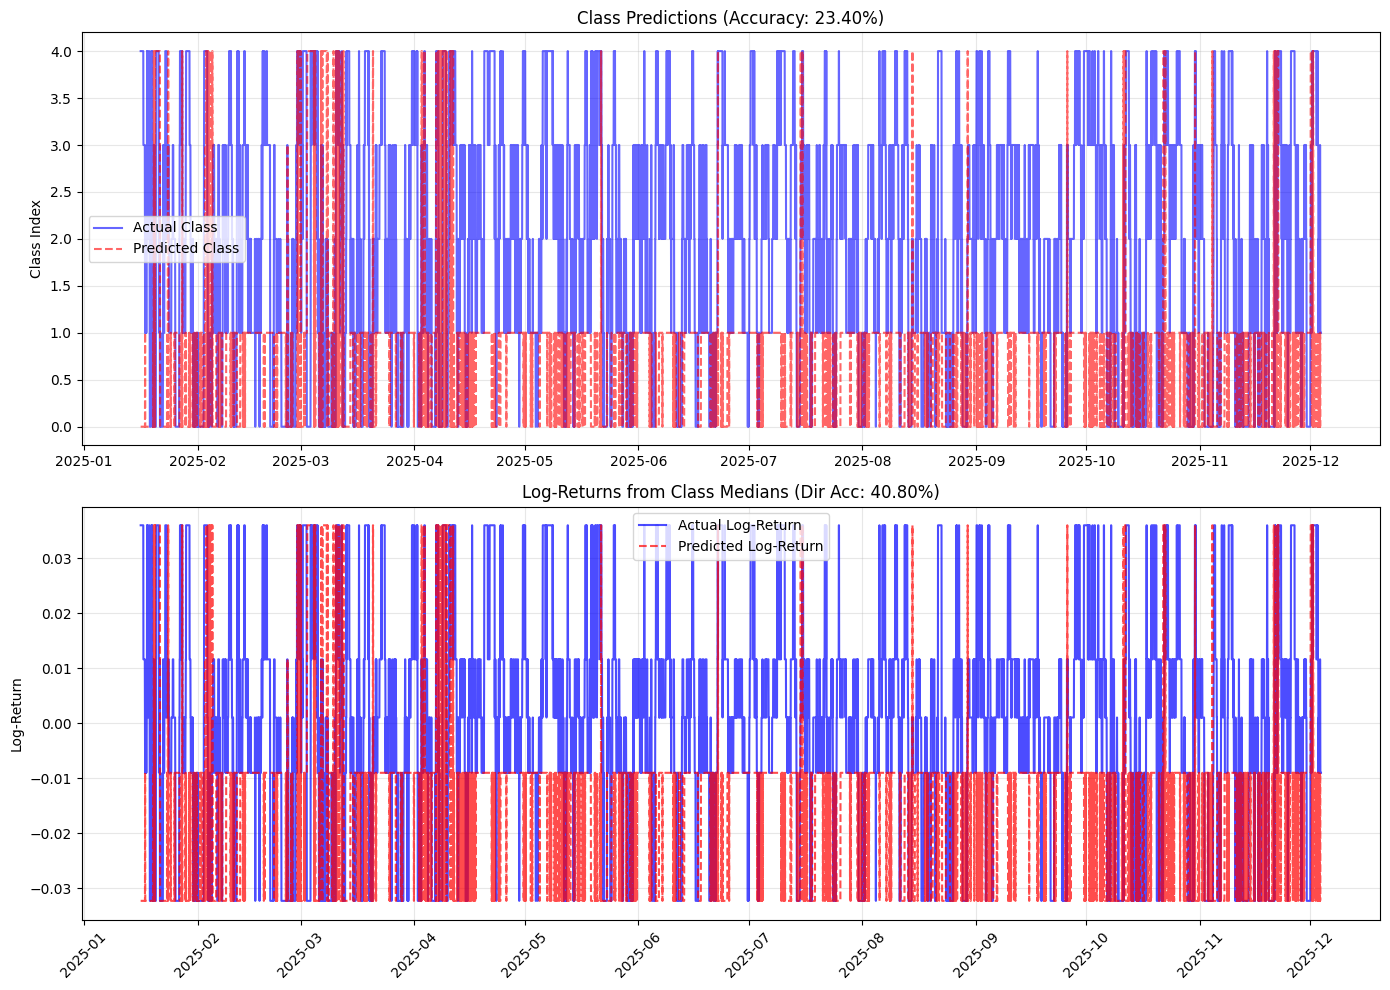

In [ ]:
# acc 23, dir acc 40

if __name__ == "__main__":
    LOOKBACK = 120
    BATCH_SIZE = 128
    EPOCHS = 20
    D_MODEL = 128
    N_LAYERS = 2
    N_BINS = 5
    CSV_FILE = 'btc_1h_2020-2025_training_sample_with_bins.csv'
    CACHE_FILE = 'processed_data_cache.pkl'
    MODEL_PATH = 'best_mamba_classifier.pth'

    data_dict, train_loader, val_loader, test_loader = get_data_loaders(
        filename=CSV_FILE,
        lookback=LOOKBACK,
        batch_size=BATCH_SIZE,
        cache_file=CACHE_FILE,
        n_bins=N_BINS,
        classification_mode=True,
        force_reprocess=False
    )

    input_dim = data_dict['X_train'].shape[2]
    n_classes = data_dict['n_classes']
    class_labels = data_dict['class_labels']
    class_medians = data_dict['class_medians']

    from sklearn.utils.class_weight import compute_class_weight
    class_weights_np = compute_class_weight('balanced', classes=np.unique(data_dict['y_train']), y=data_dict['y_train'])
    class_weights_tensor = torch.FloatTensor(class_weights_np)
    print(f"Class weights: {class_weights_tensor}")

    model = MambaModel(
        input_dim=input_dim,
        n_classes=n_classes,
        d_model=D_MODEL,
        n_layers=N_LAYERS,
        use_mamba=True
    ).to(device)

    history = run_training_classification(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS,
        learning_rate=3e-4,
        early_stop_patience=10,
        model_path=MODEL_PATH,
        class_weights=class_weights_tensor
    )

    if history is not None:
        evaluate_classification(
            model=model,
            test_loader=test_loader,
            class_medians=class_medians,
            class_labels=class_labels,
            time_index=data_dict['time_index']['test'],
            model_path=MODEL_PATH
        )

In [ ]:
if __name__ == "__main__":
    LOOKBACK = 60
    BATCH_SIZE = 128
    EPOCHS = 20
    D_MODEL = 128
    N_LAYERS = 2
    N_BINS = 5
    CSV_FILE = 'btc_1h_2020-2025_training_sample_with_bins.csv'
    CACHE_FILE = 'processed_data_cache.pkl'
    MODEL_PATH = 'best_mamba_classifier.pth'

    data_dict, train_loader, val_loader, test_loader = get_data_loaders(
        filename=CSV_FILE,
        lookback=LOOKBACK,
        batch_size=BATCH_SIZE,
        cache_file=CACHE_FILE,
        n_bins=N_BINS,
        classification_mode=True,
        force_reprocess=False
    )

    from collections import Counter
    from sklearn.metrics import accuracy_score

    most_common_class = Counter(data_dict['y_train']).most_common(1)[0][0]

    naive_preds = [most_common_class] * len(data_dict['y_test'])

    acc_naive = accuracy_score(data_dict['y_test'], naive_preds)

    print("-" * 30)
    print(f"BASELINE CHECK:")
    print(f"Most common class in Train: {most_common_class}")
    print(f"Naive Accuracy (always predict class {most_common_class}): {acc_naive:.4f} ({acc_naive:.2%})")
    print("-" * 30)
    print("Если ваша модель покажет Accuracy ниже или близко к этому значению,")
    print("значит, она НЕ обучилась ничему полезному.")
    print("-" * 30)

Загрузка кэшированных данных из processed_data_cache.pkl_60_5_True...
Данные готовы: Train=36221, Val=7714, Test=7715
Режим: Классификация
Количество классов: 5
Распределение классов в train: {np.int64(0): np.int64(7496), np.int64(1): np.int64(7058), np.int64(2): np.int64(7106), np.int64(3): np.int64(6882), np.int64(4): np.int64(7679)}
------------------------------
BASELINE CHECK:
Most common class in Train: 4
Naive Accuracy (always predict class 4): 0.1348 (13.48%)
------------------------------
Если ваша модель покажет Accuracy ниже или близко к этому значению,
значит, она НЕ обучилась ничему полезному.
------------------------------
